Zadania 1

In [3]:
import numpy as np
import scipy.linalg as la
from scipy.linalg import solve_triangular
from scipy.sparse.linalg import cg
from time import perf_counter


# METODY ROZWIĄZYWANIA UKŁADÓW


def inverse_method(A, b):
    return np.linalg.inv(A) @ b


def lu_inverse_method(A, b):
    P, L, U = la.lu(A)
    return np.linalg.inv(U) @ np.linalg.inv(L) @ P.T @ b


def lu_triangular_method(A, b):
    P, L, U = la.lu(A)

    y = solve_triangular(L, P.T @ b, lower=True)
    x = solve_triangular(U, y)

    return x


def qr_inverse_method(A, b):
    Q, R = np.linalg.qr(A)

    return np.linalg.inv(R) @ Q.T @ b


def qr_triangular_method(A, b):
    Q, R = np.linalg.qr(A)

    y = Q.T @ b
    x = solve_triangular(R, y)

    return x


def iterative_method(A, b):
    x, info = cg(A, b, maxiter=5000)

    if info != 0:
        print("CG nie osiągnęło zbieżności")

    return x


def solve_method(A, b):
    return np.linalg.solve(A, b)



# NARZĘDZIA


def residual_norm(A, x, b):
    return np.linalg.norm(A @ x - b)


def benchmark(method, A, b, repeats=20):

    start = perf_counter()

    for _ in range(repeats):
        x = method(A, b)

    elapsed = (perf_counter() - start) / repeats

    return x, elapsed


def test_matrix(A, b):

    print("\n" + "=" * 80)

    cond = np.linalg.cond(A)

    print(f"Rozmiar: {A.shape}")
    print(f"Condition number: {cond:.4e}")

    methods = {
        "Inverse": inverse_method,
        "LU inverse": lu_inverse_method,
        "LU triangular": lu_triangular_method,
        "QR inverse": qr_inverse_method,
        "QR triangular": qr_triangular_method,
        "CG iterative": iterative_method,
        "NumPy solve": solve_method
    }

    print("\n{:20s} {:15s} {:15s}".format(
        "Metoda",
        "Residual",
        "Time [s]"
    ))

    print("-" * 55)

    for name, method in methods.items():

        try:
            x, t = benchmark(method, A, b)

            res = residual_norm(A, x, b)

            print(
                "{:20s} {:15.4e} {:15.6f}".format(
                    name,
                    res,
                    t
                )
            )

        except Exception as e:

            print(
                "{:20s} {}".format(
                    name,
                    f"ERROR: {e}"
                )
            )



# MACIERZ HILBERTA


print("\nMACIERZ HILBERTA")

n = 15

A = la.hilbert(n)
b = np.random.rand(n)

test_matrix(A, b)


# MACIERZE LOSOWE SPD


for n in [100, 1000]:

    print(f"\n\nMACIERZ LOSOWA SPD {n}x{n}")

    M = np.random.uniform(0, 100, (n, n))

    # symetryczna dodatnio określona
    A = M.T @ M + np.eye(n)

    b = np.random.uniform(0, 100, n)

    test_matrix(A, b)


# PRZYPADEK 1 000 000 x 1 000 000


print("\n" + "=" * 80)
print("Macierz 1 000 000 x 1 000 000")
print("Nie jest możliwe przechowanie jej w pamięci RAM.")
print("Macierz float64 wymagałaby około 8 TB pamięci.")
print("W praktyce należy stosować macierze rzadkie i metody iteracyjne.")


MACIERZ HILBERTA

Rozmiar: (15, 15)
Condition number: 3.6757e+17

Metoda               Residual        Time [s]       
-------------------------------------------------------
Inverse                   8.1590e-01        0.000091
LU inverse                7.0786e-01        0.000421
LU triangular             6.2304e-01        0.000476
QR inverse                2.7807e+00        0.000086
QR triangular             6.2096e-01        0.000068
CG nie osiągnęło zbieżności
CG nie osiągnęło zbieżności
CG nie osiągnęło zbieżności
CG nie osiągnęło zbieżności
CG nie osiągnęło zbieżności
CG nie osiągnęło zbieżności
CG nie osiągnęło zbieżności
CG nie osiągnęło zbieżności
CG nie osiągnęło zbieżności
CG nie osiągnęło zbieżności
CG nie osiągnęło zbieżności
CG nie osiągnęło zbieżności
CG nie osiągnęło zbieżności
CG nie osiągnęło zbieżności
CG nie osiągnęło zbieżności
CG nie osiągnęło zbieżności
CG nie osiągnęło zbieżności
CG nie osiągnęło zbieżności
CG nie osiągnęło zbieżności
CG nie osiągnęło zbieżności

Zadanie 2

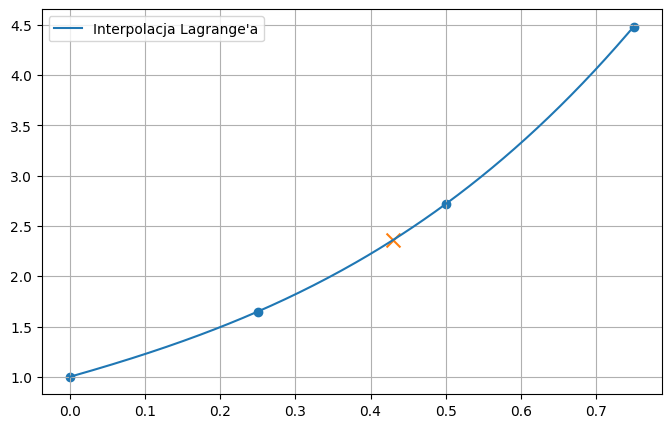

f(0.43) = 2.360604734079999


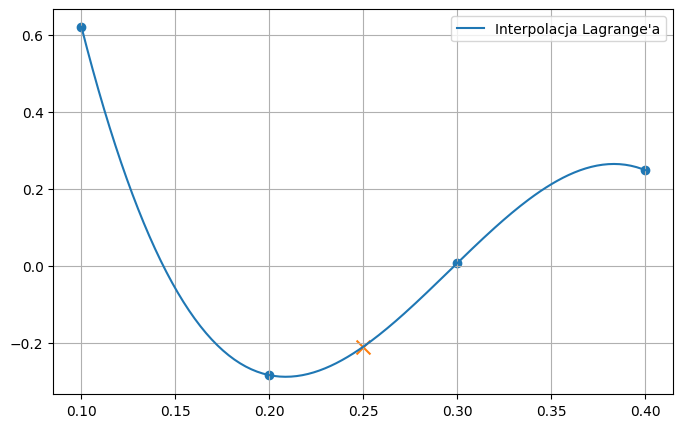

f2(0.25) = -0.21033722187500237


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange

x = np.array([0, 0.25, 0.5, 0.75])
y = np.array([1, 1.64872, 2.71828, 4.48169])

p = lagrange(x, y)

x_plot = np.linspace(0, 0.75, 200)

plt.figure(figsize=(8,5))
plt.plot(x_plot, p(x_plot), label="Interpolacja Lagrange'a")
plt.scatter(x, y)
plt.scatter([0.43], [p(0.43)], marker='x', s=100)
plt.grid()
plt.legend()
plt.show()

print("f(0.43) =", p(0.43))

x2 = np.array([0.1,0.2,0.3,0.4])
y2 = np.array([0.62049958,-0.28398668,0.00660095,0.24842440])

p2 = lagrange(x2,y2)

x_plot = np.linspace(0.1,0.4,200)

plt.figure(figsize=(8,5))
plt.plot(x_plot,p2(x_plot),label="Interpolacja Lagrange'a")
plt.scatter(x2,y2)
plt.scatter([0.25],[p2(0.25)],marker='x',s=100)
plt.grid()
plt.legend()
plt.show()

print("f2(0.25) =", p2(0.25))

Zadanie 3

Przedział [-2,2]


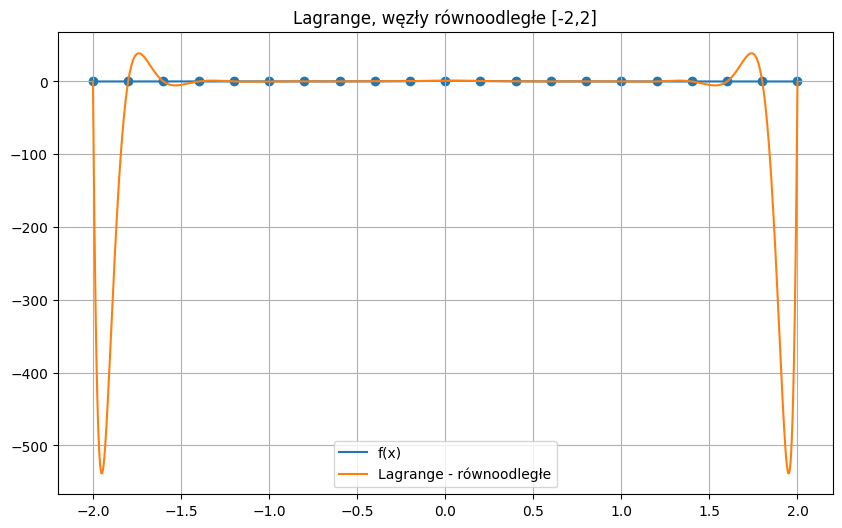

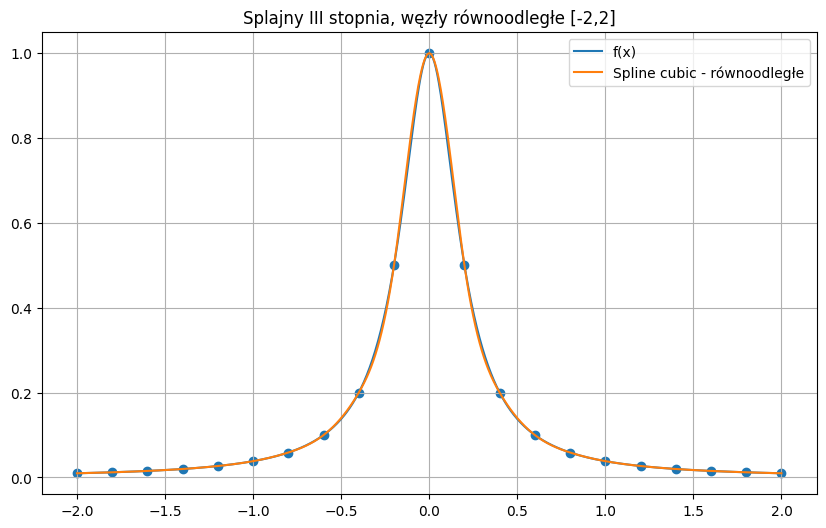

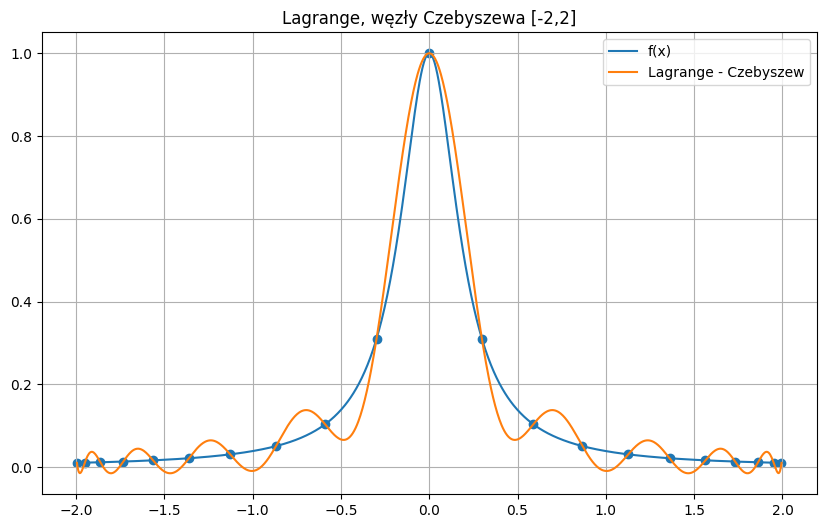

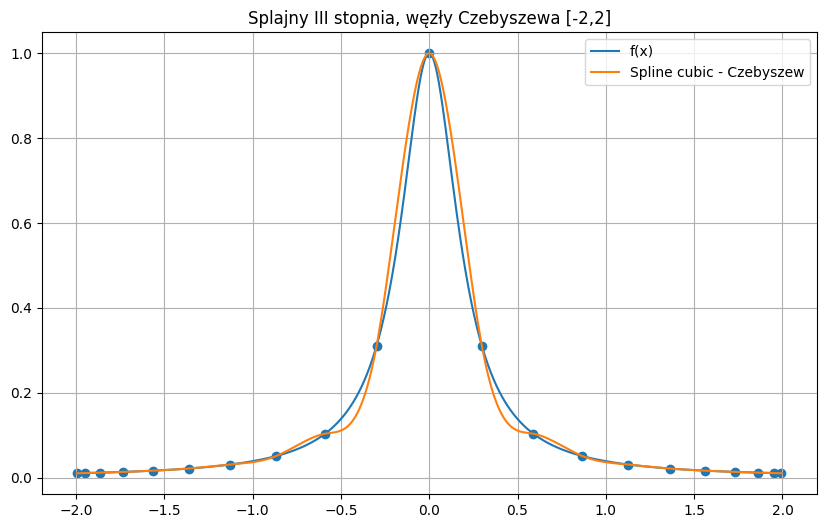

Przedział [-5,5]


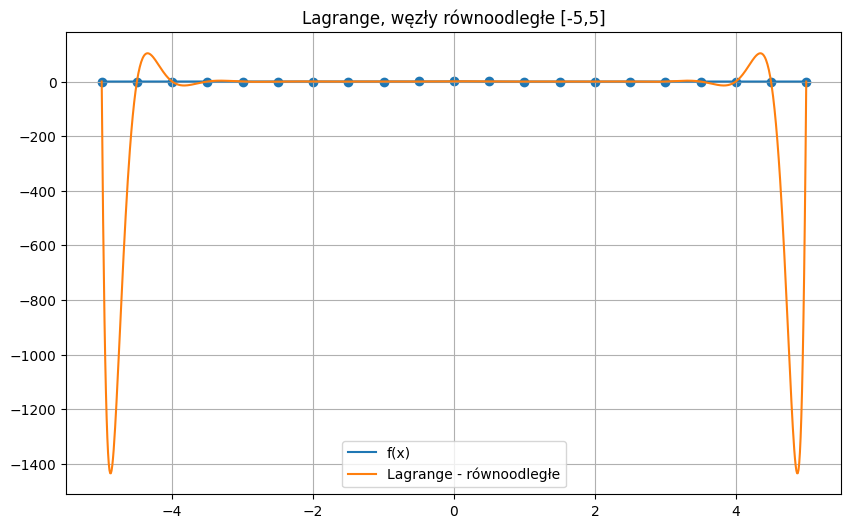

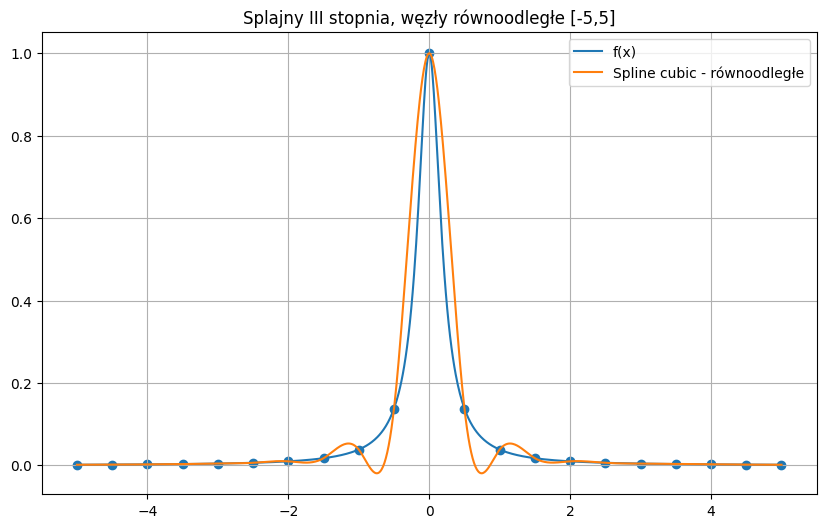

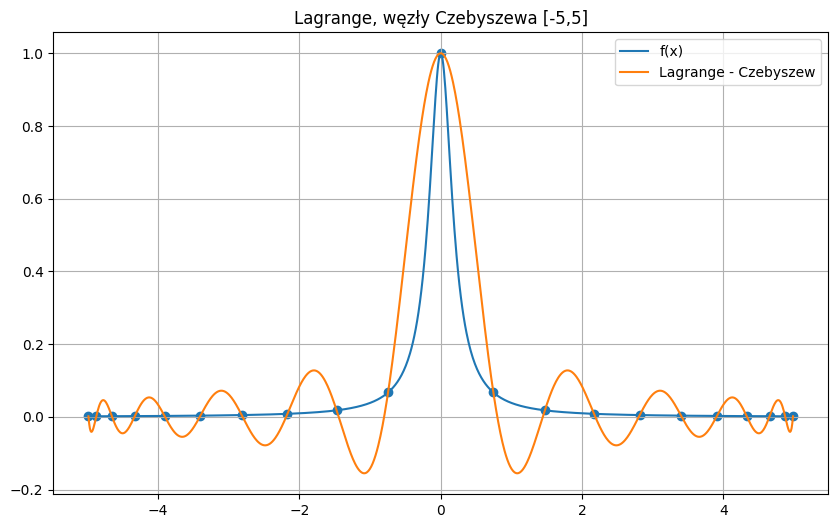

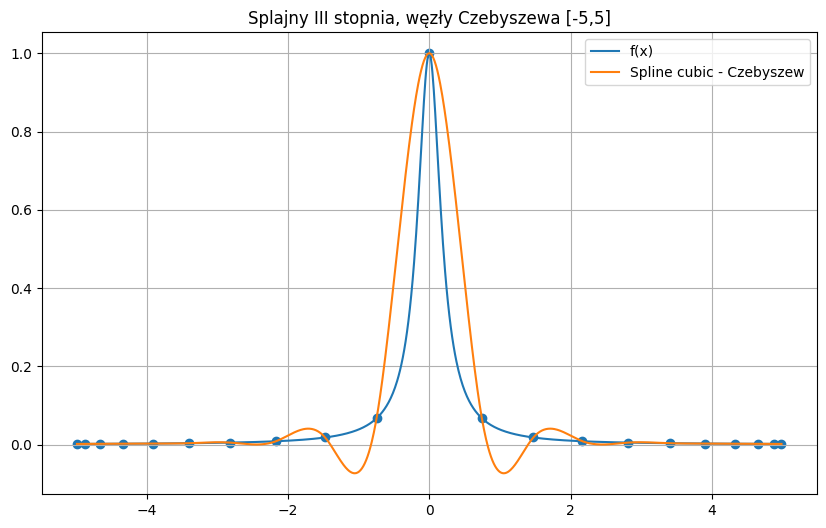

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange, interp1d

# ==========================================================
# FUNKCJA RUNGEGO
# ==========================================================

def f(x):
    return 1 / (25 * x**2 + 1)


# ==========================================================
# FUNKCJA RYSUJĄCA WYKRESY
# ==========================================================

def interpolation_comparison(a, b, n=21):

    # ------------------------------------------------------
    # WĘZŁY RÓWNOODLEGŁE
    # ------------------------------------------------------

    x_eq = np.linspace(a, b, n)
    y_eq = f(x_eq)

    lag_eq = lagrange(x_eq, y_eq)
    spline_eq = interp1d(x_eq, y_eq, kind='cubic')

    x_dense = np.linspace(a, b, 1000)

    # Lagrange - węzły równoodległe

    plt.figure(figsize=(10, 6))
    plt.plot(x_dense, f(x_dense), label='f(x)')
    plt.plot(x_dense, lag_eq(x_dense),
             label='Lagrange - równoodległe')
    plt.scatter(x_eq, y_eq)

    plt.title(f'Lagrange, węzły równoodległe [{a},{b}]')
    plt.grid()
    plt.legend()
    plt.show()

    # Splajny - węzły równoodległe

    plt.figure(figsize=(10, 6))
    plt.plot(x_dense, f(x_dense), label='f(x)')
    plt.plot(x_dense, spline_eq(x_dense),
             label='Spline cubic - równoodległe')
    plt.scatter(x_eq, y_eq)

    plt.title(f'Splajny III stopnia, węzły równoodległe [{a},{b}]')
    plt.grid()
    plt.legend()
    plt.show()

    # ------------------------------------------------------
    # WĘZŁY CZEBYSZEWA
    # ------------------------------------------------------

    k = np.arange(n)

    x_cheb = 0.5 * (a + b) + \
             0.5 * (b - a) * np.cos((2 * k + 1) * np.pi / (2 * n))

    idx = np.argsort(x_cheb)

    x_cheb = x_cheb[idx]
    y_cheb = f(x_cheb)

    lag_cheb = lagrange(x_cheb, y_cheb)

    spline_cheb = interp1d(
        x_cheb,
        y_cheb,
        kind='cubic'
    )

    x_dense_cheb = np.linspace(
        np.min(x_cheb),
        np.max(x_cheb),
        1000
    )

    # Lagrange - Czebyszew

    plt.figure(figsize=(10, 6))
    plt.plot(x_dense_cheb, f(x_dense_cheb), label='f(x)')
    plt.plot(x_dense_cheb,
             lag_cheb(x_dense_cheb),
             label='Lagrange - Czebyszew')

    plt.scatter(x_cheb, y_cheb)

    plt.title(f'Lagrange, węzły Czebyszewa [{a},{b}]')
    plt.grid()
    plt.legend()
    plt.show()

    # Splajny - Czebyszew

    plt.figure(figsize=(10, 6))
    plt.plot(x_dense_cheb, f(x_dense_cheb), label='f(x)')
    plt.plot(x_dense_cheb,
             spline_cheb(x_dense_cheb),
             label='Spline cubic - Czebyszew')

    plt.scatter(x_cheb, y_cheb)

    plt.title(f'Splajny III stopnia, węzły Czebyszewa [{a},{b}]')
    plt.grid()
    plt.legend()
    plt.show()


# ==========================================================
# PRZEDZIAŁ [-2,2]
# ==========================================================

print("Przedział [-2,2]")
interpolation_comparison(-2, 2, n=21)

# ==========================================================
# PRZEDZIAŁ [-5,5]
# ==========================================================

print("Przedział [-5,5]")
interpolation_comparison(-5, 5, n=21)